<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/ECO006.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

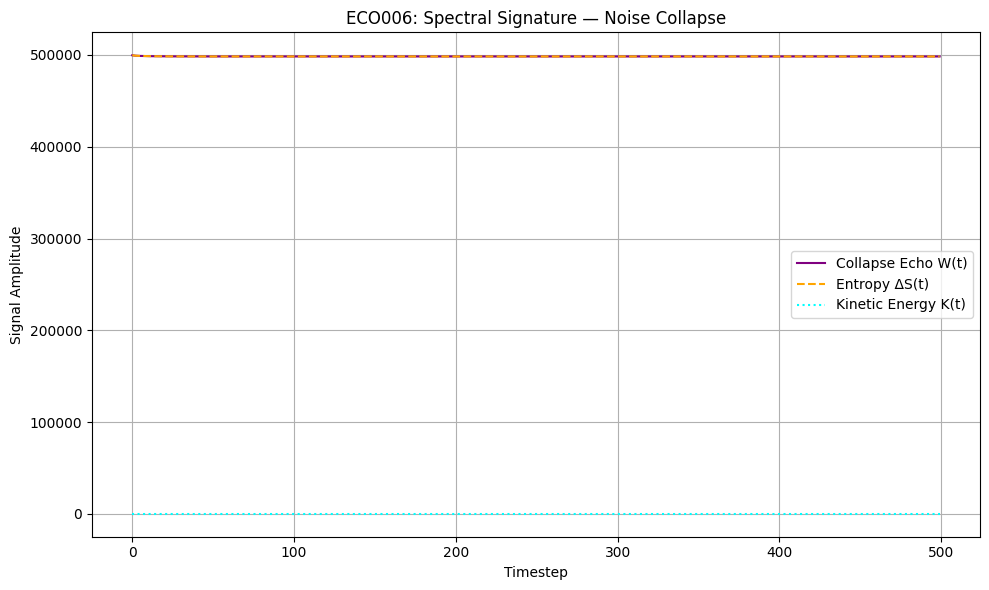

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ECO006: Collapse in Noise Field — Act XXXVI

# Parameters
N = 100
timesteps = 500
alpha = 2.0
beta = 0.1
num_particles = 50
include_particles = True

# Noise entropy field
def noise_entropy(N):
    return np.random.rand(N, N, N)

# Initialize particles
def initialize_particles(num, N):
    positions = np.random.randint(0, N, size=(num, 3))
    velocities = np.random.randn(num, 3) * 0.5
    return positions, velocities

# Collapse + waveform extraction
def simulate_waveform(entropy, alpha, beta, include_particles):
    waveform = []
    entropy_trace = []
    fidelity_trace = []
    kinetic_trace = []

    if include_particles:
        positions, velocities = initialize_particles(num_particles, N)

    for t in range(timesteps):
        gradient = np.gradient(entropy)
        magnitude = np.sqrt(sum(g**2 for g in gradient))
        non_zero_mag = magnitude[magnitude > 1e-9]
        if non_zero_mag.size == 0:
            break
        mu_grad = np.mean(non_zero_mag)
        sigma_grad = np.std(non_zero_mag)
        adaptive_threshold = alpha * mu_grad + beta * sigma_grad

        collapse_mask = magnitude > adaptive_threshold
        entropy[collapse_mask] *= 0.9
        fidelity = np.sum(collapse_mask)
        entropy_total = np.sum(entropy)

        # Particle update
        kinetic_energy = 0.0
        if include_particles:
            for i in range(len(positions)):
                pos = positions[i]
                vel = velocities[i]
                new_pos = np.clip(pos + vel.astype(int), 0, N-1)
                if collapse_mask[tuple(new_pos)]:
                    velocities[i] *= 0.5
                positions[i] = new_pos
                kinetic_energy += np.sum(vel**2)

        # Record waveform
        waveform.append(entropy_total + 0.1 * kinetic_energy)
        entropy_trace.append(entropy_total)
        fidelity_trace.append(fidelity)
        kinetic_trace.append(kinetic_energy)

        if entropy_total < 1e-6:
            break

    return waveform, entropy_trace, fidelity_trace, kinetic_trace

# Initialize field
entropy = noise_entropy(N)

# Run simulation
waveform, entropy_trace, fidelity_trace, kinetic_trace = simulate_waveform(
    entropy.copy(), alpha, beta, include_particles
)

# Plot waveform
plt.figure(figsize=(10, 6))
plt.plot(waveform, label='Collapse Echo W(t)', color='purple')
plt.plot(entropy_trace, label='Entropy ΔS(t)', linestyle='--', color='orange')
plt.plot(kinetic_trace, label='Kinetic Energy K(t)', linestyle=':', color='cyan')
plt.title("ECO006: Spectral Signature — Noise Collapse")
plt.xlabel("Timestep")
plt.ylabel("Signal Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
